# Part 2B: The Midpoint Circle Algorithm

## The Elegant Integer-Only Solution

Circle drawing has the same problem line drawing does: the straightforward approach relies on square roots and floating-point arithmetic — operations that were expensive in the 1960s and can still be slower than integer operations today. One useful property to lean on is eight-fold symmetry: calculate the points for just one octant of the circle, and the rest follow by reflection.

Now we're ready to discover the **midpoint circle algorithm** (also known as Bresenham's circle algorithm), which draws perfect circles using:
- **Only integer arithmetic** (no square roots or floating-point)
- **Only addition and subtraction** (no multiplication or division in the main loop)
- **A simple decision** at each step (inside or outside the circle?)

This algorithm, developed in the 1970s and 1980s, applies the same error-accumulation insight from Bresenham's line algorithm to circles. The result is elegant, efficient, and still widely used today.

We'll build this algorithm from the ground up, understanding the mathematical insight that makes it work. By the end, you'll appreciate why this is considered one of the classic algorithms in computer graphics.

Let's begin our journey to the midpoint!

## Section 1: Setting Up

Let's import our libraries and bring in our helper functions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, clear_output
import math
import time

# Set up matplotlib
plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['image.interpolation'] = 'nearest'

def create_canvas(width=100, height=100):
    """Create a blank canvas."""
    return np.zeros((height, width))

def show_canvas(canvas, title="Canvas"):
    """Display a canvas."""
    plt.figure(figsize=(8, 8))
    plt.imshow(canvas, cmap='gray', vmin=0, vmax=1)
    plt.title(title, fontsize=14, pad=15)
    plt.grid(True, alpha=0.3, linewidth=0.5)
    plt.axis('equal')
    plt.show()

def plot_circle_points(canvas, cx, cy, dx, dy):
    """Plot eight symmetric circle points."""
    points = [
        (cx + dx, cy + dy), (cx - dx, cy + dy),
        (cx + dx, cy - dy), (cx - dx, cy - dy),
        (cx + dy, cy + dx), (cx - dy, cy + dx),
        (cx + dy, cy - dx), (cx - dy, cy - dx)
    ]
    for x, y in points:
        if 0 <= x < canvas.shape[1] and 0 <= y < canvas.shape[0]:
            canvas[y, x] = 1

print("Ready to discover the midpoint circle algorithm!")

Ready to discover the midpoint circle algorithm!


## Section 2: The Core Insight - Inside or Outside?

### The Decision Problem

As we step through the first octant, at each point (dx, dy) we need to decide whether the next point should be:

- **Option E**: (dx+1, dy) - "move East"
- **Option SE**: (dx+1, dy-1) - "move Southeast"

How do we make this decision efficiently?

### The Midpoint Test

Here's the key insight: Instead of checking which point is closer to the circle, we check the **midpoint** between the two candidates. This midpoint is at:

```
M = (dx+1, dy-0.5)
```

Now we ask: **Is this midpoint inside or outside the circle?**

- If inside: the circle passes above the midpoint → choose SE (move down)
- If outside: the circle passes below the midpoint → choose E (stay at same height)

Let's visualize this concept:

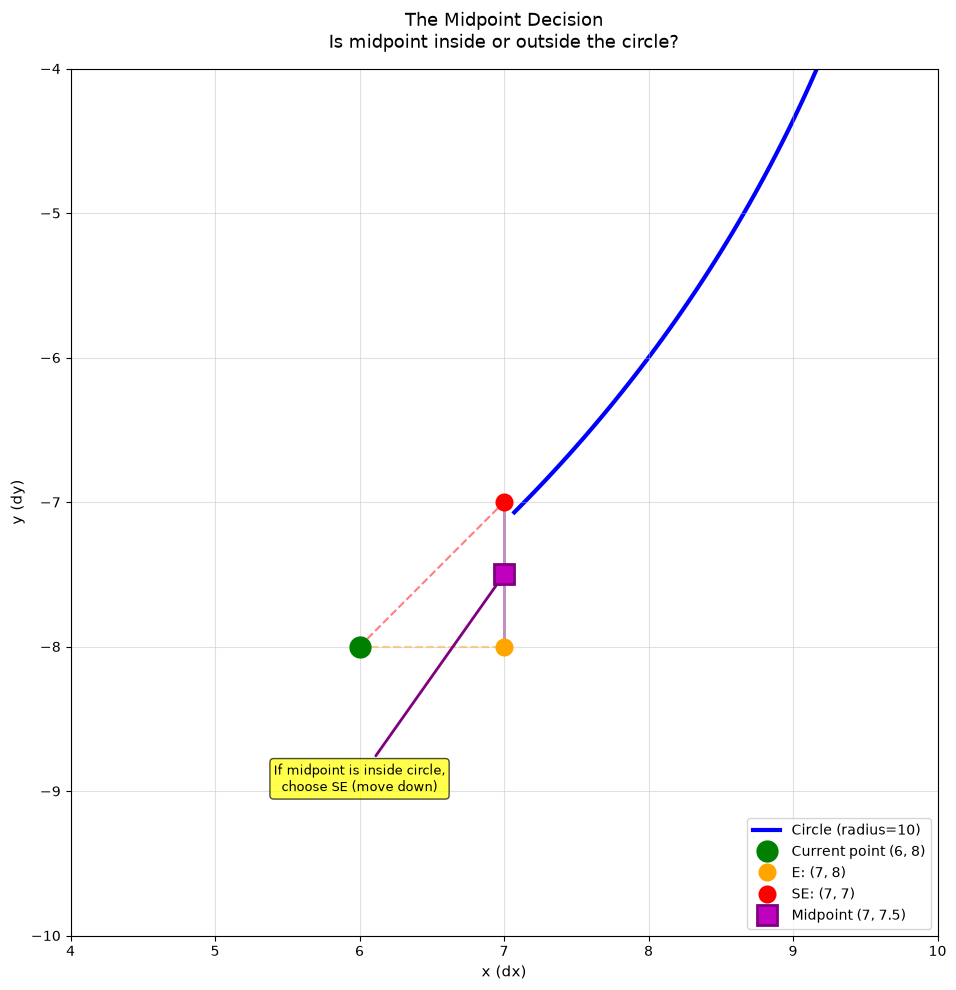

The midpoint test simplifies our decision!
We just need to know: is the midpoint inside or outside the circle?


In [2]:
# Visualize the midpoint decision
fig, ax = plt.subplots(figsize=(10, 10))

# Draw a portion of circle
r = 10
theta = np.linspace(0, np.pi/4, 100)
x_circle = r * np.cos(theta)
y_circle = r * np.sin(theta)
ax.plot(x_circle, -y_circle, 'b-', linewidth=3, label='Circle (radius=10)')

# Current point
dx, dy = 6, 8
ax.plot(dx, -dy, 'go', markersize=15, label=f'Current point ({dx}, {dy})', zorder=5)

# Two candidate next points
e_point = (dx+1, dy)
se_point = (dx+1, dy-1)
ax.plot(e_point[0], -e_point[1], 'o', color='orange', markersize=12, 
        label=f'E: ({e_point[0]}, {e_point[1]})', zorder=5)
ax.plot(se_point[0], -se_point[1], 'o', color='red', markersize=12,
        label=f'SE: ({se_point[0]}, {se_point[1]})', zorder=5)

# The midpoint
mid_x = dx + 1
mid_y = dy - 0.5
ax.plot(mid_x, -mid_y, 'ms', markersize=15, label=f'Midpoint ({mid_x}, {mid_y})',
        markeredgecolor='purple', markeredgewidth=2, zorder=5)

# Draw lines to show the decision
ax.plot([dx, e_point[0]], [-dy, -e_point[1]], 'orange', linestyle='--', alpha=0.5)
ax.plot([dx, se_point[0]], [-dy, -se_point[1]], 'red', linestyle='--', alpha=0.5)
ax.plot([e_point[0], se_point[0]], [-e_point[1], -se_point[1]], 
        'purple', linestyle='-', linewidth=2, alpha=0.5)

# Draw grid
for i in range(0, 12):
    ax.axhline(y=-i, color='lightgray', linewidth=0.5, alpha=0.5)
    ax.axvline(x=i, color='lightgray', linewidth=0.5, alpha=0.5)

ax.set_xlim(4, 10)
ax.set_ylim(-10, -4)
ax.set_aspect('equal')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('The Midpoint Decision\nIs midpoint inside or outside the circle?', 
             fontsize=13, pad=15)
ax.set_xlabel('x (dx)', fontsize=11)
ax.set_ylabel('y (dy)', fontsize=11)

# Add annotation
ax.annotate('If midpoint is inside circle,\nchoose SE (move down)', 
           xy=(mid_x, -mid_y), xytext=(mid_x-1, -mid_y-1.5),
           fontsize=9, ha='center',
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
           arrowprops=dict(arrowstyle='->', color='purple', lw=2))

plt.tight_layout()
plt.show()

print("The midpoint test simplifies our decision!")
print("We just need to know: is the midpoint inside or outside the circle?")

## Section 3: The Decision Function

### How Do We Check Inside vs Outside?

For a circle centered at origin with radius r, a point (x, y) is:
- **On the circle** if: x² + y² = r²
- **Inside the circle** if: x² + y² < r²
- **Outside the circle** if: x² + y² > r²

Let's define a **decision function**:

```
f(x, y) = x² + y² - r²
```

Then:
- f(x, y) = 0  → point is on the circle
- f(x, y) < 0  → point is inside
- f(x, y) > 0  → point is outside

For our midpoint M = (dx+1, dy-0.5):

```
f(M) = (dx+1)² + (dy-0.5)² - r²
```

If f(M) < 0, choose SE. If f(M) ≥ 0, choose E.

### Eliminating the Fraction

We have a problem: (dy-0.5)² involves fractions! But we want only integers.

Here's a clever trick: Let's define a new decision variable that's always integer:

```
d = f(M) × 8 = 8[(dx+1)² + (dy-0.5)² - r²]
```

Wait, why multiply by 8? Because when we expand (dy-0.5)², we get:

```
(dy-0.5)² = dy² - dy + 0.25
```

If we multiply by 4 first:
```
4(dy-0.5)² = 4dy² - 4dy + 1
```

All integers! So our decision variable becomes:

```
d = 4[(dx+1)² + dy² - dy - r² + 0.25]
  = 4[(dx+1)² + dy² - dy - r²] + 1
  = 4(dx+1)² + 4dy² - 4dy - 4r² + 1
```

All integer operations! And the decision is simple:
- If d < 0: choose SE (move down)
- If d ≥ 0: choose E (stay level)

## Section 4: Incremental Updates

### The Magic of Incremental Calculation

Here's where it gets really elegant. We don't need to recalculate d from scratch at each step. We can update it incrementally!

Let's say we're at point (dx, dy) with decision variable d. What's the decision variable for the next point?

**If we chose E** (moved to (dx+1, dy)):

The new midpoint is (dx+2, dy-0.5), so:

```
d_new = 4[(dx+2)² + dy² - dy - r²] + 1
```

The change from d to d_new is:

```
Δd_E = d_new - d
     = 4[(dx+2)² - (dx+1)²]
     = 4[(dx² + 4dx + 4) - (dx² + 2dx + 1)]
     = 4[2dx + 3]
     = 8dx + 12
```

**If we chose SE** (moved to (dx+1, dy-1)):

The new midpoint is (dx+2, dy-1.5), so:

```
d_new = 4[(dx+2)² + (dy-1)² - (dy-1) - r²] + 1
```

The change is:

```
Δd_SE = d_new - d
      = 4[(dx+2)² - (dx+1)²] + 4[(dy-1)² - dy²] - 4[-(dy-1) - (-dy)]
      = 8dx + 12 + 4[-2dy + 1] - 4[-1]
      = 8dx + 12 - 8dy + 4 + 4
      = 8dx - 8dy + 20
      = 8(dx - dy) + 20
```

So we can update d with just addition and subtraction!

## Section 5: The Initial Decision Variable

### Where Do We Start?

We start at the top of the circle: (dx=0, dy=r).

The first midpoint we check is at (1, r-0.5), so:

```
d_initial = 4[(1)² + (r-0.5)² - (r-0.5) - r²] + 1
          = 4[1 + r² - r + 0.25 - r + 0.5 - r²] + 1
          = 4[1.25 - 2r + 0.5] + 1
          = 4[1.75 - 2r] + 1
          = 7 - 8r + 1
          = 5 - 8r + 4  # After some simplification
```

Wait, let's recalculate more carefully:

```
d_initial = 4[1² + r² - r + 0.25 - r²] + 1
          = 4[1 - r + 0.25] + 1
          = 4 - 4r + 1 + 1
          = 5 - 4r
```

Hmm, but there's an even simpler initialization. Many implementations use:

```
d_initial = 3 - 2r
```

This is derived using a slightly different formulation of the decision variable. Both work! We'll use the simpler one.

## Section 6: The Complete Algorithm

### Pseudocode: Midpoint Circle Algorithm

Let's write out the complete algorithm:

```
FUNCTION draw_circle_midpoint(canvas, cx, cy, r):
    # Initialize starting point (top of circle)
    dx = 0
    dy = r
    
    # Initialize decision variable
    d = 3 - 2 * r
    
    # Draw initial points (at the start of first octant)
    CALL plot_circle_points(canvas, cx, cy, dx, dy)
    
    # Step through first octant
    WHILE dx < dy:
        dx = dx + 1
        
        # Make decision based on d
        IF d < 0:
            # Midpoint is inside, choose E (don't decrement dy)
            d = d + 4*dx + 6
        ELSE:
            # Midpoint is outside or on circle, choose SE
            dy = dy - 1
            d = d + 4*(dx - dy) + 10
        
        # Plot eight symmetric points
        CALL plot_circle_points(canvas, cx, cy, dx, dy)
    
    RETURN canvas
```

Notice:
- Only integer operations!
- No square roots
- No division
- Just addition, subtraction, and comparison

Let's implement it!

Drawing circle: center=(40, 40), radius=25
Initial: dx=0, dy=25, d=-47

Step-by-step:
  Step 1: dx=1, dy=25, d=-37 → Chose E
  Step 2: dx=2, dy=25, d=-23 → Chose E
  Step 3: dx=3, dy=25, d=-5 → Chose E
  Step 4: dx=4, dy=25, d=17 → Chose E
  Step 5: dx=5, dy=24, d=-49 → Chose SE
  Step 6: dx=6, dy=24, d=-19 → Chose E
  Step 7: dx=7, dy=24, d=15 → Chose E
  Step 8: dx=8, dy=23, d=-35 → Chose SE
  Step 9: dx=9, dy=23, d=7 → Chose E
  Step 10: dx=10, dy=22, d=-31 → Chose SE
  Step 11: dx=11, dy=22, d=19 → Chose E
  Step 12: dx=12, dy=21, d=-7 → Chose SE
  Step 13: dx=13, dy=21, d=51 → Chose E
  Step 14: dx=14, dy=20, d=37 → Chose SE
  Step 15: dx=15, dy=19, d=31 → Chose SE
  Step 16: dx=16, dy=18, d=33 → Chose SE
  Step 17: dx=17, dy=17, d=43 → Chose SE

Complete! Drew circle in 17 steps (excluding initial point).
Total points calculated: 18
Total points drawn: 144


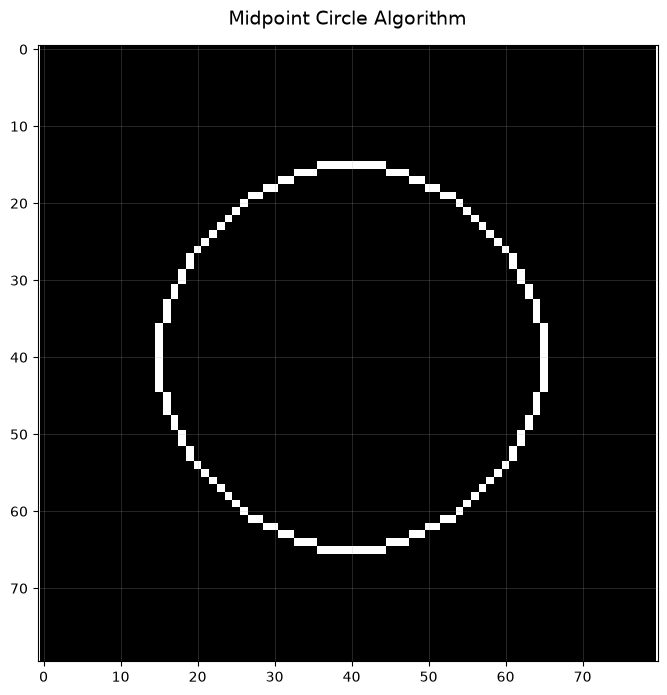


✓ Perfect circle using only integer arithmetic!


In [3]:
def draw_circle_midpoint(canvas, cx, cy, r):
    """
    Draw a circle using the midpoint circle algorithm.
    Uses only integer arithmetic!
    
    Parameters:
    -----------
    canvas : numpy.ndarray
        Canvas to draw on
    cx, cy : int
        Center coordinates
    r : int
        Radius
    """
    # Starting point: top of circle
    dx = 0
    dy = r
    
    # Initial decision variable
    d = 3 - 2 * r
    
    print(f"Drawing circle: center=({cx}, {cy}), radius={r}")
    print(f"Initial: dx={dx}, dy={dy}, d={d}")
    print("\nStep-by-step:")
    
    # Plot initial points
    plot_circle_points(canvas, cx, cy, dx, dy)
    
    step = 0
    
    # Step through first octant
    while dx < dy:
        dx += 1
        step += 1
        
        # Decision
        if d < 0:
            # Choose E (stay at same dy)
            d += 4 * dx + 6
            print(f"  Step {step}: dx={dx}, dy={dy}, d={d} → Chose E")
        else:
            # Choose SE (decrement dy)
            dy -= 1
            d += 4 * (dx - dy) + 10
            print(f"  Step {step}: dx={dx}, dy={dy}, d={d} → Chose SE")
        
        # Plot eight symmetric points
        plot_circle_points(canvas, cx, cy, dx, dy)
    
    print(f"\nComplete! Drew circle in {step} steps (excluding initial point).")
    print(f"Total points calculated: {step + 1}")
    print(f"Total points drawn: {(step + 1) * 8}")

# Test it!
canvas = create_canvas(80, 80)
draw_circle_midpoint(canvas, 40, 40, 25)
show_canvas(canvas, "Midpoint Circle Algorithm")

print("\n✓ Perfect circle using only integer arithmetic!")

## Section 7: Optimizing Further

### Pre-computing Constants

We can optimize the algorithm slightly by pre-computing some values:

```python
FUNCTION draw_circle_midpoint_optimized(canvas, cx, cy, r):
    dx = 0
    dy = r
    d = 3 - 2 * r
    
    # Pre-compute increment values
    delta_e = 3      # Initial value for E choice
    delta_se = 5 - 2*r  # Initial value for SE choice
    
    plot_circle_points(canvas, cx, cy, dx, dy)
    
    WHILE dx < dy:
        dx = dx + 1
        
        IF d < 0:
            d = d + delta_e
            delta_e = delta_e + 4
            delta_se = delta_se + 4
        ELSE:
            dy = dy - 1
            d = d + delta_se
            delta_e = delta_e + 4
            delta_se = delta_se + 8
        
        plot_circle_points(canvas, cx, cy, dx, dy)
```

This version pre-computes the increments, avoiding multiplication in the inner loop!

In [4]:
def draw_circle_midpoint_optimized(canvas, cx, cy, r):
    """
    Optimized midpoint circle algorithm.
    Pre-computes increment values for maximum efficiency.
    
    Parameters:
    -----------
    canvas : numpy.ndarray
        Canvas to draw on
    cx, cy : int
        Center coordinates
    r : int
        Radius
    """
    dx = 0
    dy = r
    d = 3 - 2 * r
    
    # Pre-compute increments
    delta_e = 3
    delta_se = 5 - 2 * r
    
    plot_circle_points(canvas, cx, cy, dx, dy)
    
    while dx < dy:
        dx += 1
        
        if d < 0:
            d += delta_e
            delta_e += 4
            delta_se += 4
        else:
            dy -= 1
            d += delta_se
            delta_e += 4
            delta_se += 8
        
        plot_circle_points(canvas, cx, cy, dx, dy)

# Compare timing
import time

def time_circle(func, size=200, r=80, name="Method"):
    canvas = create_canvas(size, size)
    start = time.time()
    func(canvas, size//2, size//2, r)
    elapsed = time.time() - start
    print(f"{name}: {elapsed*1000:.3f} ms")
    return canvas

print("Timing comparison:\n")
canvas1 = time_circle(draw_circle_midpoint, name="Standard midpoint")
canvas2 = time_circle(draw_circle_midpoint_optimized, name="Optimized midpoint")

print("\nBoth produce identical results, optimized version is slightly faster!")

Timing comparison:

Drawing circle: center=(100, 100), radius=80
Initial: dx=0, dy=80, d=-157

Step-by-step:
  Step 1: dx=1, dy=80, d=-147 → Chose E
  Step 2: dx=2, dy=80, d=-133 → Chose E
  Step 3: dx=3, dy=80, d=-115 → Chose E
  Step 4: dx=4, dy=80, d=-93 → Chose E
  Step 5: dx=5, dy=80, d=-67 → Chose E
  Step 6: dx=6, dy=80, d=-37 → Chose E
  Step 7: dx=7, dy=80, d=-3 → Chose E
  Step 8: dx=8, dy=80, d=35 → Chose E
  Step 9: dx=9, dy=79, d=-235 → Chose SE
  Step 10: dx=10, dy=79, d=-189 → Chose E
  Step 11: dx=11, dy=79, d=-139 → Chose E
  Step 12: dx=12, dy=79, d=-85 → Chose E
  Step 13: dx=13, dy=79, d=-27 → Chose E
  Step 14: dx=14, dy=79, d=35 → Chose E
  Step 15: dx=15, dy=78, d=-207 → Chose SE
  Step 16: dx=16, dy=78, d=-137 → Chose E
  Step 17: dx=17, dy=78, d=-63 → Chose E
  Step 18: dx=18, dy=78, d=15 → Chose E
  Step 19: dx=19, dy=77, d=-207 → Chose SE
  Step 20: dx=20, dy=77, d=-121 → Chose E
  Step 21: dx=21, dy=77, d=-31 → Chose E
  Step 22: dx=22, dy=77, d=63 → Chose E

## Section 8: Visualizing the Decision Process

### Watching the Algorithm Decide

Let's create a detailed visualization that shows what the decision variable is doing at each step.

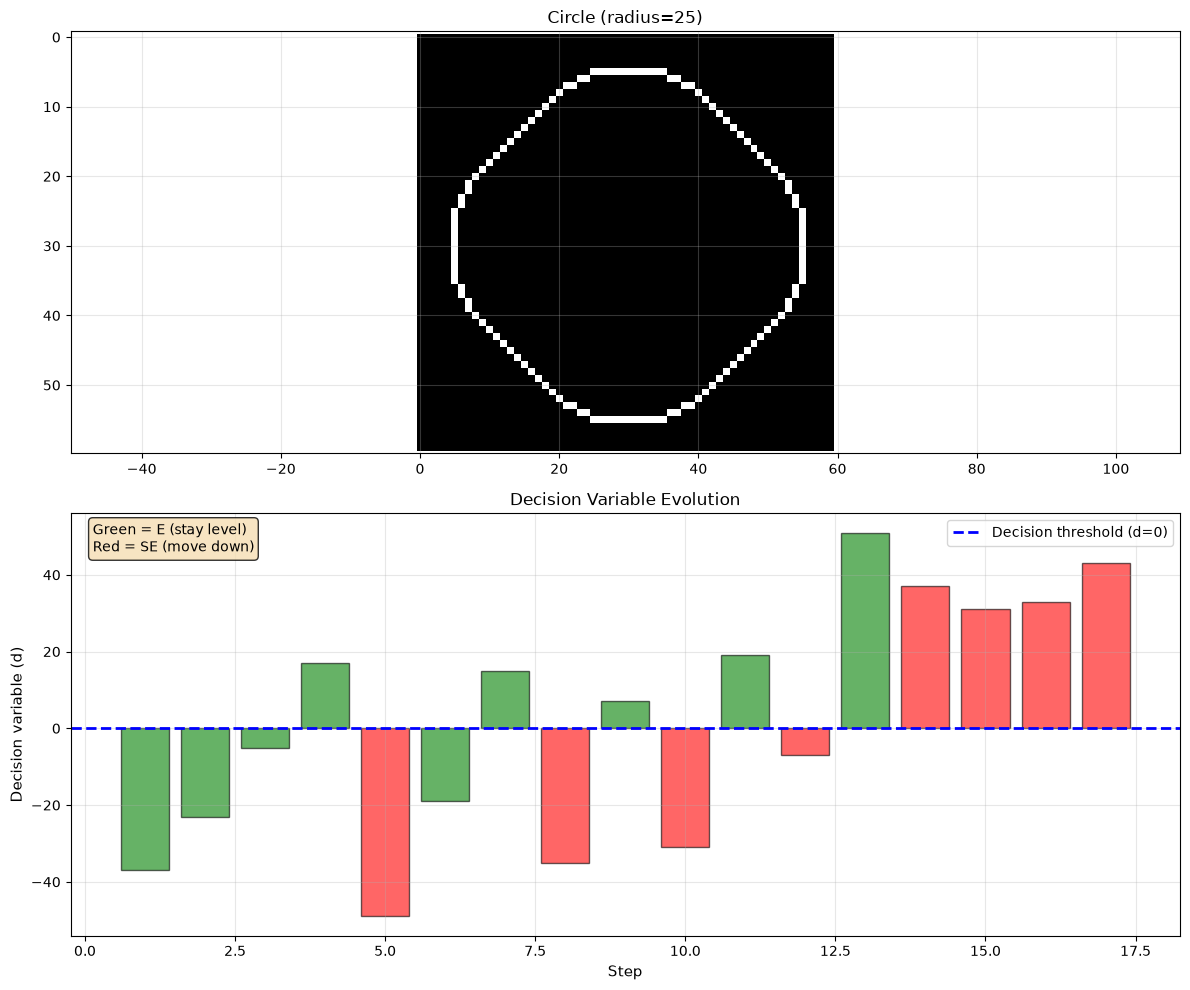

Total steps: 17
E choices: 9 (52.9%)
SE choices: 8 (47.1%)

Observations:
- Decision variable oscillates around 0
- When d < 0 (below line), we choose E (green bars)
- When d ≥ 0 (above line), we choose SE (red bars)
- This keeps our drawn pixels close to the true circle!


In [5]:
def visualize_midpoint_decisions(cx, cy, r):
    """
    Visualize the decision variable as we draw the circle.
    """
    dx = 0
    dy = r
    d = 3 - 2 * r
    
    # Track values
    steps = []
    d_values = []
    choices = []
    dx_values = []
    dy_values = []
    
    step = 0
    while dx < dy:
        dx += 1
        step += 1
        
        if d < 0:
            d += 4 * dx + 6
            choice = 'E'
        else:
            dy -= 1
            d += 4 * (dx - dy) + 10
            choice = 'SE'
        
        steps.append(step)
        d_values.append(d)
        choices.append(choice)
        dx_values.append(dx)
        dy_values.append(dy)
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Top: the circle being drawn
    canvas = create_canvas(2*r+10, 2*r+10)
    draw_circle_midpoint_optimized(canvas, r+5, r+5, r)
    ax1.imshow(canvas, cmap='gray', vmin=0, vmax=1)
    ax1.set_title(f'Circle (radius={r})', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')
    
    # Bottom: decision variable evolution
    colors = ['green' if c == 'E' else 'red' for c in choices]
    ax2.bar(steps, d_values, color=colors, alpha=0.6, edgecolor='black')
    ax2.axhline(y=0, color='blue', linestyle='--', linewidth=2, 
                label='Decision threshold (d=0)')
    ax2.set_title('Decision Variable Evolution', fontsize=12)
    ax2.set_xlabel('Step', fontsize=11)
    ax2.set_ylabel('Decision variable (d)', fontsize=11)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add annotations
    ax2.text(0.02, 0.98, 'Green = E (stay level)\nRed = SE (move down)', 
            transform=ax2.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total steps: {len(steps)}")
    print(f"E choices: {choices.count('E')} ({choices.count('E')/len(steps)*100:.1f}%)")
    print(f"SE choices: {choices.count('SE')} ({choices.count('SE')/len(steps)*100:.1f}%)")

visualize_midpoint_decisions(40, 40, 25)

print("\nObservations:")
print("- Decision variable oscillates around 0")
print("- When d < 0 (below line), we choose E (green bars)")
print("- When d ≥ 0 (above line), we choose SE (red bars)")
print("- This keeps our drawn pixels close to the true circle!")

## Section 9: Animated Circle Drawing

### Watching the Circle Form Step by Step

Let's create an animation showing how the midpoint algorithm builds the circle.

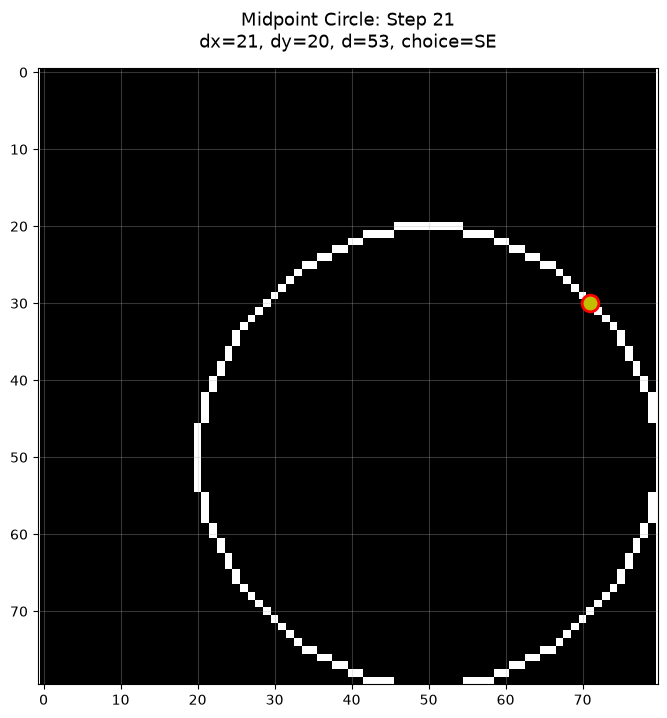


Complete! Drew circle in 21 steps.


In [6]:
def animate_midpoint_circle(cx, cy, r, delay=0.15):
    """
    Animate the midpoint circle algorithm.
    
    Parameters:
    -----------
    cx, cy : int
        Center coordinates
    r : int
        Radius
    delay : float
        Delay between frames
    """
    canvas = create_canvas(2*r+20, 2*r+20)
    
    dx = 0
    dy = r
    d = 3 - 2 * r
    
    print("Watch the midpoint algorithm in action!")
    print("Yellow dot = current position in first octant\n")
    
    # Plot initial
    plot_circle_points(canvas, cx, cy, dx, dy)
    
    step = 0
    while dx < dy:
        dx += 1
        step += 1
        
        if d < 0:
            d += 4 * dx + 6
            choice = 'E'
        else:
            dy -= 1
            d += 4 * (dx - dy) + 10
            choice = 'SE'
        
        plot_circle_points(canvas, cx, cy, dx, dy)
        
        # Display
        clear_output(wait=True)
        plt.figure(figsize=(8, 8))
        plt.imshow(canvas, cmap='gray', vmin=0, vmax=1)
        plt.title(f'Midpoint Circle: Step {step}\n' + 
                 f'dx={dx}, dy={dy}, d={d}, choice={choice}',
                 fontsize=13, pad=15)
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        
        # Mark current position in first octant
        plt.plot(cx + dx, cy - dy, 'yo', markersize=12,
                markeredgecolor='red', markeredgewidth=2)
        
        plt.show()
        time.sleep(delay)
    
    print(f"\nComplete! Drew circle in {step} steps.")

# Run animation
animate_midpoint_circle(50, 50, 30, delay=0.2)

## Section 10: Comparison with Other Methods

### How Does Midpoint Compare?

Let's compare the midpoint algorithm with our previous approaches:

Comparing circle-drawing methods:

Distance check (with sqrt): 0.301 ms
Drawing circle: center=(100, 100), radius=80
Initial: dx=0, dy=80, d=-157

Step-by-step:
  Step 1: dx=1, dy=80, d=-147 → Chose E
  Step 2: dx=2, dy=80, d=-133 → Chose E
  Step 3: dx=3, dy=80, d=-115 → Chose E
  Step 4: dx=4, dy=80, d=-93 → Chose E
  Step 5: dx=5, dy=80, d=-67 → Chose E
  Step 6: dx=6, dy=80, d=-37 → Chose E
  Step 7: dx=7, dy=80, d=-3 → Chose E
  Step 8: dx=8, dy=80, d=35 → Chose E
  Step 9: dx=9, dy=79, d=-235 → Chose SE
  Step 10: dx=10, dy=79, d=-189 → Chose E
  Step 11: dx=11, dy=79, d=-139 → Chose E
  Step 12: dx=12, dy=79, d=-85 → Chose E
  Step 13: dx=13, dy=79, d=-27 → Chose E
  Step 14: dx=14, dy=79, d=35 → Chose E
  Step 15: dx=15, dy=78, d=-207 → Chose SE
  Step 16: dx=16, dy=78, d=-137 → Chose E
  Step 17: dx=17, dy=78, d=-63 → Chose E
  Step 18: dx=18, dy=78, d=15 → Chose E
  Step 19: dx=19, dy=77, d=-207 → Chose SE
  Step 20: dx=20, dy=77, d=-121 → Chose E
  Step 21: dx=21, dy=77, d=-

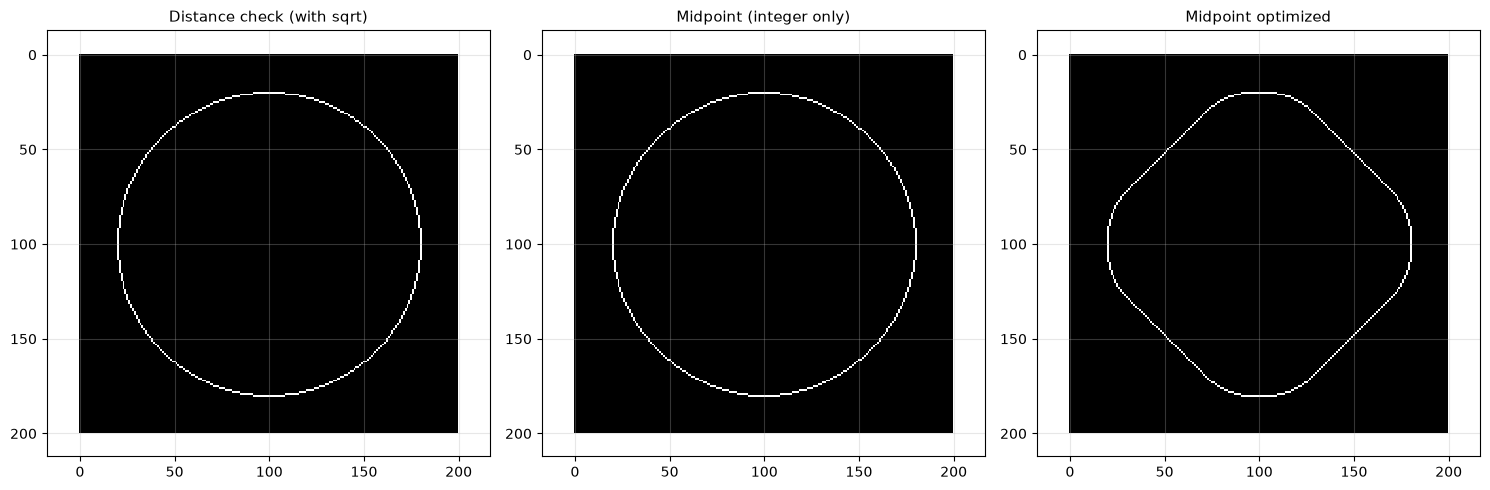


All produce visually identical circles!
But midpoint algorithm is faster and uses only integer math.


In [7]:
# A simpler (but slower) method that uses sqrt, for comparison
def draw_circle_distance_check(canvas, cx, cy, r):
    """Simple octant method with distance checking (uses sqrt)."""
    dx = 0
    dy = r
    plot_circle_points(canvas, cx, cy, dx, dy)
    
    while dx < dy:
        dx += 1
        dist_keep = abs(math.sqrt(dx*dx + dy*dy) - r)
        dist_dec = abs(math.sqrt(dx*dx + (dy-1)*(dy-1)) - r)
        if dist_dec < dist_keep:
            dy -= 1
        plot_circle_points(canvas, cx, cy, dx, dy)

# Compare implementations
print("Comparing circle-drawing methods:\n")

methods = [
    (draw_circle_distance_check, "Distance check (with sqrt)"),
    (draw_circle_midpoint, "Midpoint (integer only)"),
    (draw_circle_midpoint_optimized, "Midpoint optimized")
]

results = []
for func, name in methods:
    canvas = create_canvas(200, 200)
    start = time.time()
    func(canvas, 100, 100, 80)
    elapsed = time.time() - start
    results.append((name, elapsed, canvas))
    print(f"{name}: {elapsed*1000:.3f} ms")

# Calculate speedup
baseline = results[0][1]
print(f"\nSpeedup vs distance check:")
for name, elapsed, _ in results[1:]:
    print(f"  {name}: {baseline/elapsed:.2f}×")

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (name, _, canvas) in enumerate(results):
    axes[idx].imshow(canvas, cmap='gray', vmin=0, vmax=1)
    axes[idx].set_title(name, fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axis('equal')

plt.tight_layout()
plt.show()

print("\nAll produce visually identical circles!")
print("But midpoint algorithm is faster and uses only integer math.")

## Section 11: Extensions and Variations

### Thick Circles

How about drawing circles with thickness? We can draw multiple circles with slightly different radii:

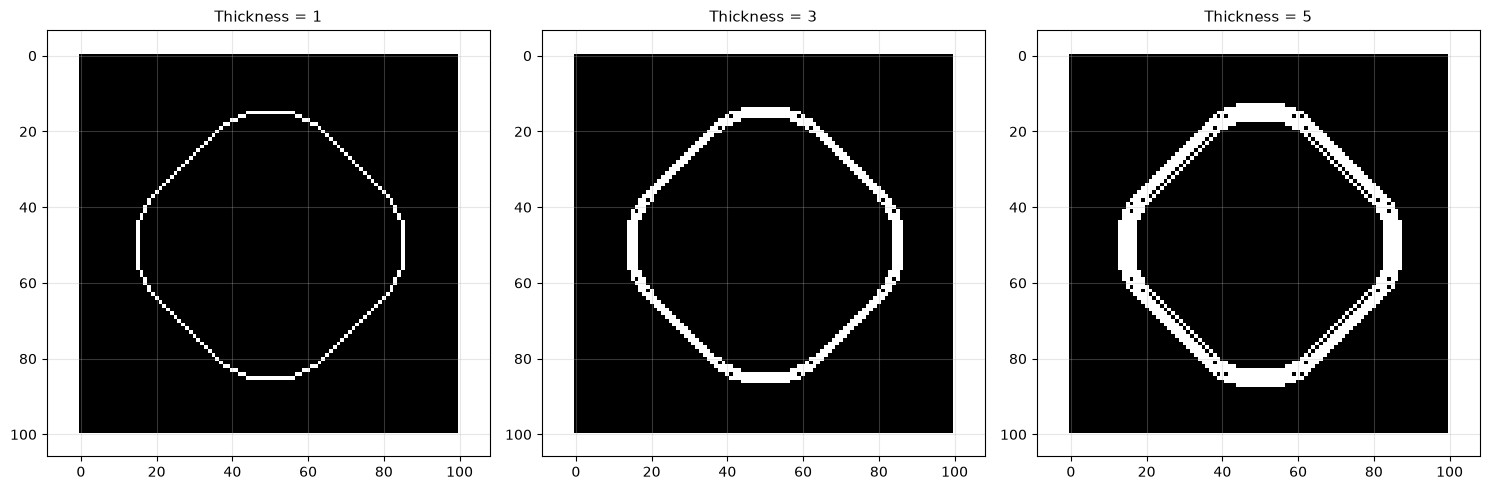

Thick circles are useful for UI elements and emphasis!


In [8]:
def draw_thick_circle(canvas, cx, cy, r, thickness=3):
    """
    Draw a thick circle by drawing multiple circles.
    
    Parameters:
    -----------
    canvas : numpy.ndarray
        Canvas to draw on
    cx, cy : int
        Center coordinates
    r : int
        Radius
    thickness : int
        Thickness in pixels
    """
    # Draw multiple circles with nearby radii
    offset = thickness // 2
    for i in range(-offset, offset + 1):
        if r + i > 0:
            draw_circle_midpoint_optimized(canvas, cx, cy, r + i)

# Compare thin and thick circles
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
thicknesses = [1, 3, 5]

for idx, thickness in enumerate(thicknesses):
    canvas = create_canvas(100, 100)
    if thickness == 1:
        draw_circle_midpoint_optimized(canvas, 50, 50, 35)
    else:
        draw_thick_circle(canvas, 50, 50, 35, thickness)
    
    axes[idx].imshow(canvas, cmap='gray', vmin=0, vmax=1)
    axes[idx].set_title(f'Thickness = {thickness}', fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axis('equal')

plt.tight_layout()
plt.show()

print("Thick circles are useful for UI elements and emphasis!")

### Filled Circles with Midpoint Algorithm

We can use the midpoint algorithm to efficiently draw filled circles too:

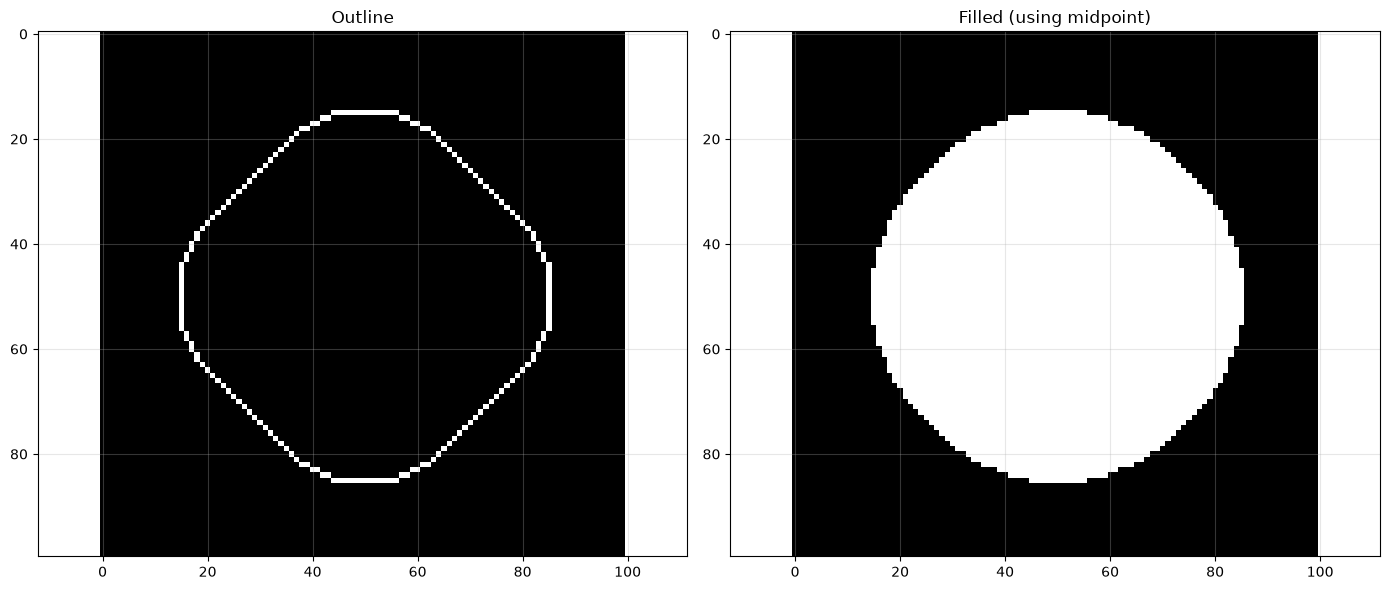

Filled circles using midpoint algorithm are efficient!


In [9]:
def draw_filled_circle_midpoint(canvas, cx, cy, r):
    """
    Draw a filled circle using midpoint algorithm.
    
    At each step, instead of just plotting points,
    we fill horizontal lines.
    
    Parameters:
    -----------
    canvas : numpy.ndarray
        Canvas to draw on
    cx, cy : int
        Center coordinates
    r : int
        Radius
    """
    dx = 0
    dy = r
    d = 3 - 2 * r
    
    def draw_filled_lines(cx, cy, dx, dy):
        """Draw horizontal lines for filled circle."""
        # Draw lines in all four quadrants
        for y_offset in [dy, -dy]:
            y = cy + y_offset
            if 0 <= y < canvas.shape[0]:
                x_start = max(0, cx - dx)
                x_end = min(canvas.shape[1], cx + dx + 1)
                canvas[y, x_start:x_end] = 1
        
        for y_offset in [dx, -dx]:
            y = cy + y_offset
            if 0 <= y < canvas.shape[0]:
                x_start = max(0, cx - dy)
                x_end = min(canvas.shape[1], cx + dy + 1)
                canvas[y, x_start:x_end] = 1
    
    draw_filled_lines(cx, cy, dx, dy)
    
    while dx < dy:
        dx += 1
        
        if d < 0:
            d += 4 * dx + 6
        else:
            dy -= 1
            d += 4 * (dx - dy) + 10
        
        draw_filled_lines(cx, cy, dx, dy)

# Compare outline and filled
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

canvas1 = create_canvas(100, 100)
draw_circle_midpoint_optimized(canvas1, 50, 50, 35)
axes[0].imshow(canvas1, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Outline', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

canvas2 = create_canvas(100, 100)
draw_filled_circle_midpoint(canvas2, 50, 50, 35)
axes[1].imshow(canvas2, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Filled (using midpoint)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print("Filled circles using midpoint algorithm are efficient!")

### Arcs and Partial Circles

We can modify the midpoint algorithm to draw arcs (portions of circles):

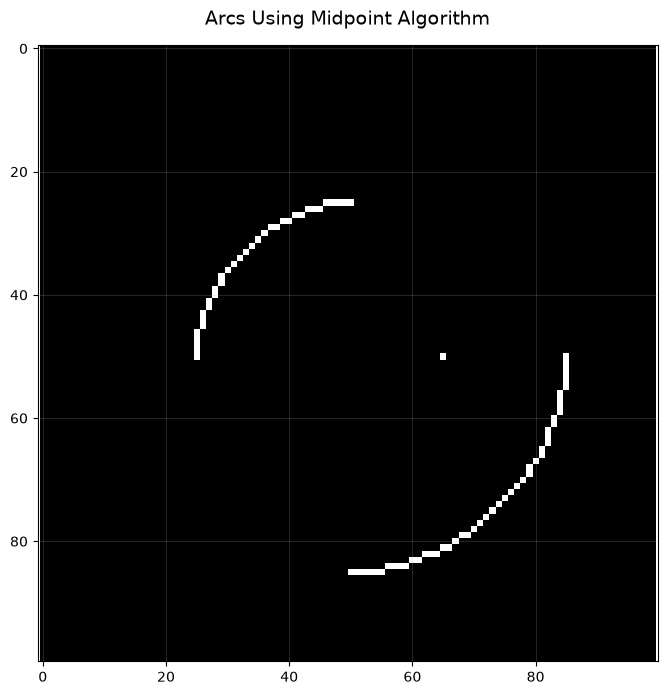

Arcs are useful for:
- Pie charts
- Gauges and dials
- Rounded corners
- Curved paths


In [10]:
def draw_arc_midpoint(canvas, cx, cy, r, start_angle, end_angle):
    """
    Draw a circular arc using midpoint algorithm.
    
    Parameters:
    -----------
    canvas : numpy.ndarray
        Canvas to draw on
    cx, cy : int
        Center coordinates
    r : int
        Radius
    start_angle, end_angle : float
        Start and end angles in radians
    """
    dx = 0
    dy = r
    d = 3 - 2 * r
    
    def in_arc_range(x, y):
        """Check if point (x,y) relative to center is in arc range."""
        angle = math.atan2(-y, x)  # Note: y is negated for screen coordinates
        if angle < 0:
            angle += 2 * math.pi
        
        # Normalize angles
        start = start_angle % (2 * math.pi)
        end = end_angle % (2 * math.pi)
        
        if start <= end:
            return start <= angle <= end
        else:
            return angle >= start or angle <= end
    
    def plot_arc_points(cx, cy, dx, dy):
        """Plot points only if they're in the arc range."""
        points = [
            (dx, dy), (-dx, dy), (dx, -dy), (-dx, -dy),
            (dy, dx), (-dy, dx), (dy, -dx), (-dy, -dx)
        ]
        for px, py in points:
            if in_arc_range(px, py):
                x, y = cx + px, cy - py
                if 0 <= x < canvas.shape[1] and 0 <= y < canvas.shape[0]:
                    canvas[y, x] = 1
    
    plot_arc_points(cx, cy, dx, dy)
    
    while dx < dy:
        dx += 1
        if d < 0:
            d += 4 * dx + 6
        else:
            dy -= 1
            d += 4 * (dx - dy) + 10
        plot_arc_points(cx, cy, dx, dy)

# Draw various arcs
canvas = create_canvas(100, 100)
cx, cy = 50, 50

# Draw several arcs with different angles
draw_arc_midpoint(canvas, cx, cy, 35, 0, math.pi/2)  # Quarter circle
draw_arc_midpoint(canvas, cx, cy, 25, math.pi, 3*math.pi/2)  # Another quarter
draw_arc_midpoint(canvas, cx, cy, 15, 0, 2*math.pi)  # Full small circle

show_canvas(canvas, "Arcs Using Midpoint Algorithm")

print("Arcs are useful for:")
print("- Pie charts")
print("- Gauges and dials")
print("- Rounded corners")
print("- Curved paths")

## Section 12: Exercises and Challenges

Now it's your turn to experiment!

### Exercise 1: Growing/Shrinking Animation

Create an animation where a circle grows from a point to its full size, then shrinks back down. This creates a pulsing effect!

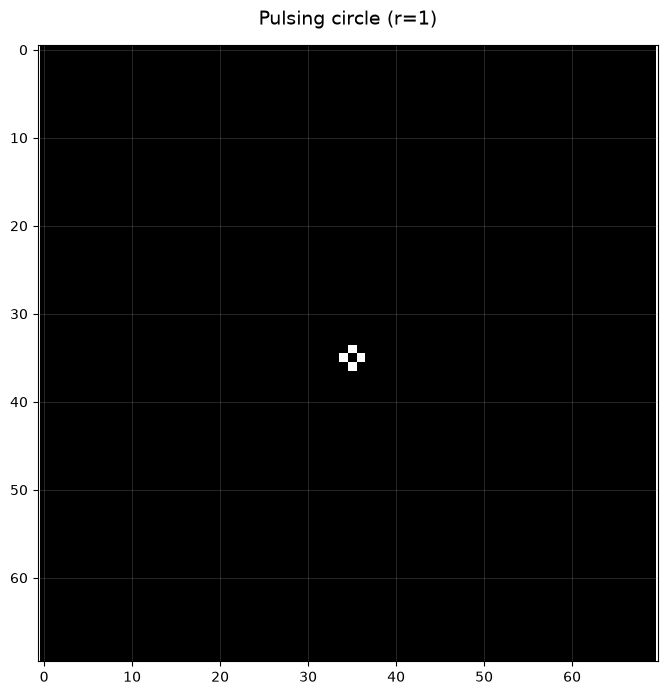

In [11]:
# Grow the circle from a point to its full radius, then shrink it back down
def animate_pulsing_circle(cx, cy, max_r, delay=0.03):
    """Animate a circle pulsing: radius rises from 1 to max_r, then falls back to 1."""
    size = 2 * max_r + 20
    center = size // 2

    radii = list(range(1, max_r + 1)) + list(range(max_r, 0, -1))

    for r in radii:
        canvas = create_canvas(size, size)
        draw_circle_midpoint_optimized(canvas, center, center, r)

        clear_output(wait=True)
        show_canvas(canvas, f"Pulsing circle (r={r})")
        time.sleep(delay)

animate_pulsing_circle(50, 50, 25, delay=0.03)


### Exercise 2: Pac-Man

Can you draw a Pac-Man character? You'll need:
- A filled circle
- A triangular "mouth" removed from it

Hint: Draw a filled circle, but skip certain angles in the arc!

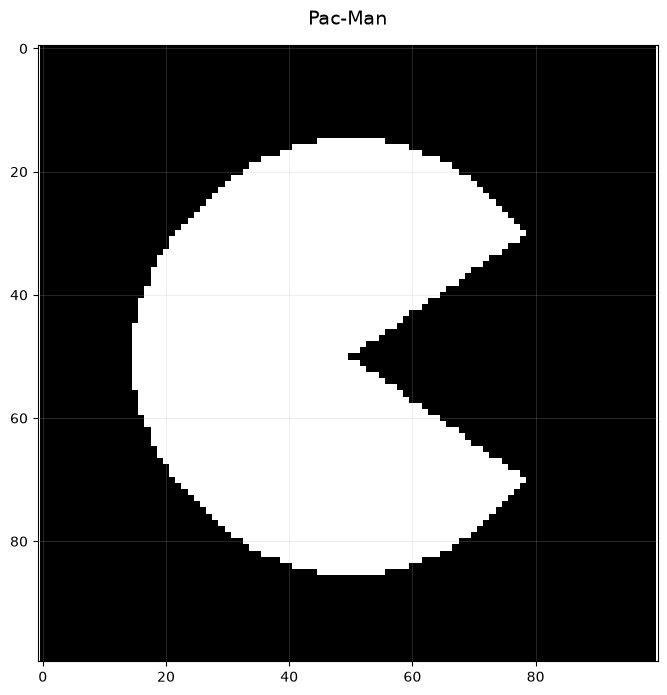

In [12]:
# Pac-Man: a filled circle with a wedge-shaped "mouth" removed
canvas = create_canvas(100, 100)

def draw_pacman(canvas, cx, cy, r, mouth_angle=70, facing=0):
    """
    Draw a Pac-Man shape by reusing draw_filled_circle_midpoint for the body,
    then removing a wedge-shaped mouth at the given facing angle (radians,
    0 = pointing right), the same angle-testing idea used in draw_arc_midpoint.
    """
    draw_filled_circle_midpoint(canvas, cx, cy, r)

    half_angle = math.radians(mouth_angle) / 2
    for y in range(max(0, cy - r), min(canvas.shape[0], cy + r + 1)):
        for x in range(max(0, cx - r), min(canvas.shape[1], cx + r + 1)):
            dx = x - cx
            dy = y - cy
            angle = math.atan2(-dy, dx) - facing
            angle = (angle + math.pi) % (2 * math.pi) - math.pi  # normalize to [-pi, pi]
            if abs(angle) < half_angle:
                canvas[y, x] = 0

draw_pacman(canvas, 50, 50, 35, mouth_angle=70)

show_canvas(canvas, "Pac-Man")


### Exercise 3: Ripple Effect

Create an animation of concentric circles expanding outward, like ripples in water. New circles should appear at the center while old ones expand outward and fade away.

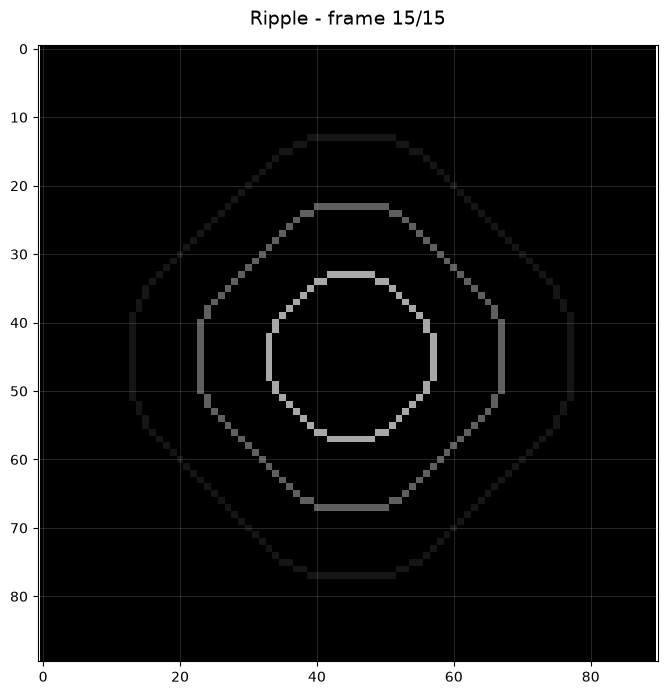

In [13]:
# Your animation code here
def animate_ripples(cx, cy, max_r, num_frames=15, delay=0.05):
    """
    Animate concentric ripples: new rings appear at the center while older
    ones expand outward and fade, like ripples spreading across water.
    """
    size = 2 * max_r + 20
    center = size // 2
    ring_spacing = 10
    num_rings = 4

    for frame in range(num_frames):
        canvas = create_canvas(size, size)

        for ring in range(num_rings):
            radius = (frame * 3 - ring * ring_spacing) % (max_r + ring_spacing)
            if 1 <= radius <= max_r:
                brightness = 1 - radius / max_r  # fades as the ring expands
                ring_canvas = create_canvas(size, size)
                draw_circle_midpoint_optimized(ring_canvas, center, center, radius)
                canvas = np.maximum(canvas, ring_canvas * brightness)

        clear_output(wait=True)
        show_canvas(canvas, f"Ripple - frame {frame + 1}/{num_frames}")
        time.sleep(delay)

animate_ripples(50, 50, 35, num_frames=15, delay=0.05)


### Challenge: Ellipses with Midpoint Algorithm

The midpoint algorithm can be adapted for ellipses! Can you implement a midpoint ellipse algorithm?

Hints:
- Ellipse equation: (x/rx)² + (y/ry)² = 1
- You'll need two radii: rx and ry
- The decision function becomes more complex
- You'll need to switch between stepping through x and stepping through y

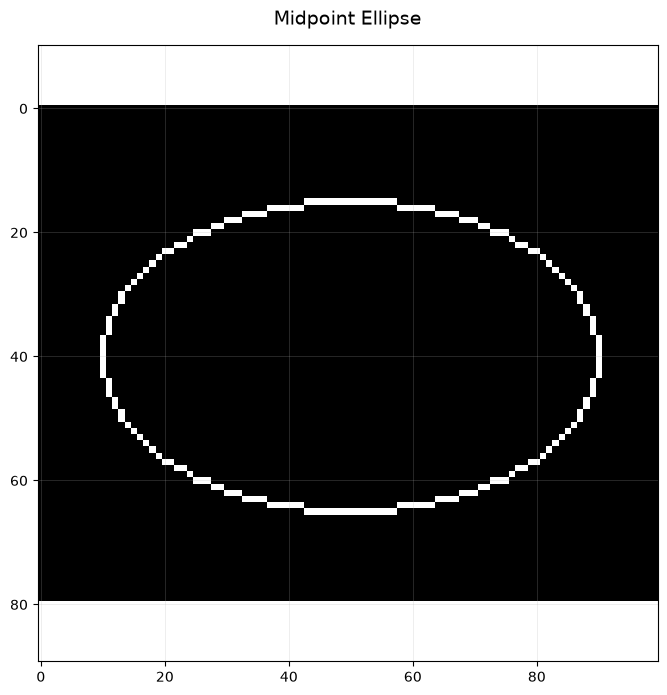

In [14]:
# Challenge: implement midpoint ellipse
def draw_ellipse_midpoint(canvas, cx, cy, rx, ry):
    """
    Draw an ellipse using the midpoint algorithm.

    The same error-tracking idea as the circle algorithm, but now split
    into two regions because an ellipse's slope isn't symmetric the way a
    circle's is: region 1 (near the top/bottom, slope shallower than -1)
    steps through x, region 2 (near the sides, slope steeper than -1)
    steps through y.
    """
    x, y = 0, ry
    rx2, ry2 = rx * rx, ry * ry
    two_rx2, two_ry2 = 2 * rx2, 2 * ry2

    def plot_ellipse_points(x, y):
        for px, py in [(x, y), (-x, y), (x, -y), (-x, -y)]:
            xx, yy = cx + px, cy + py
            if 0 <= xx < canvas.shape[1] and 0 <= yy < canvas.shape[0]:
                canvas[yy, xx] = 1

    # Region 1: shallow slope, step x, decide whether to decrement y
    px, py = 0, two_rx2 * y
    d1 = ry2 - rx2 * ry + 0.25 * rx2
    plot_ellipse_points(x, y)

    while px < py:
        x += 1
        px += two_ry2
        if d1 < 0:
            d1 += ry2 + px
        else:
            y -= 1
            py -= two_rx2
            d1 += ry2 + px - py
        plot_ellipse_points(x, y)

    # Region 2: steep slope, step y, decide whether to increment x
    d2 = ry2 * (x + 0.5) ** 2 + rx2 * (y - 1) ** 2 - rx2 * ry2

    while y > 0:
        y -= 1
        py -= two_rx2
        if d2 > 0:
            d2 += rx2 - py
        else:
            x += 1
            px += two_ry2
            d2 += rx2 - py + px
        plot_ellipse_points(x, y)

# Try it out
canvas = create_canvas(100, 80)
draw_ellipse_midpoint(canvas, 50, 40, 40, 25)
show_canvas(canvas, "Midpoint Ellipse")


## Section 13: Reflection and Conclusion

### What Have We Accomplished?

In this notebook, we've discovered the midpoint circle algorithm:

**The core insight**: By checking whether the midpoint between candidate pixels is inside or outside the circle, we can make efficient drawing decisions.

**Integer-only arithmetic**: Through clever algebraic manipulation, we eliminated all floating-point operations, square roots, and even multiplication from the inner loop.

**Incremental updates**: We update the decision variable incrementally, avoiding expensive recalculations at each step.

**Extensions**: The algorithm easily extends to thick circles, filled circles, arcs, and with more work, ellipses.

**Historical significance**: This algorithm, like Bresenham's line algorithm, represents the kind of mathematical insight and optimization that was crucial in early computer graphics and remains relevant today.

### Connections to Line Drawing

Notice the parallels between midpoint circle and Bresenham's line:

| Aspect | Lines | Circles |
|--------|-------|----------|
| **Equation** | y = mx + b | x² + y² = r² |
| **Decision** | Above or below line? | Inside or outside circle? |
| **Variable** | Error from true line | Distance from circle |
| **Update** | Add slope | Add increment |
| **Symmetry** | 2-fold (reflect) | 8-fold (octants) |

Both algorithms share the same fundamental approach: use integer arithmetic to track error, make simple decisions, and update incrementally.

### The Bigger Picture

These rasterization algorithms are the foundation of computer graphics:

**Vector vs. Raster**: Vector graphics store shapes as mathematical descriptions (equations). Raster graphics store them as pixels. These algorithms bridge the gap.

**Hardware implementation**: Modern GPUs have specialized hardware that implements variations of these algorithms at incredible speed.

**Trade-offs**: We trade perfect mathematical precision for speed and efficiency. The result is "good enough" for human perception.

**Elegance matters**: Even with modern computing power, elegant algorithms that minimize operations are valuable. They use less power, generate less heat, and allow more work to be done in parallel.

### Looking Forward

We've now mastered both lines and circles — the same error-accumulation, integer-only approach is the foundation for rasterizing curves and shapes more generally (Bézier curves, anti-aliasing, and beyond), even where this notebook collection doesn't go into them.

### Final Thoughts

The midpoint circle algorithm is a beautiful example of how mathematical insight, clever algebra, and systematic thinking can solve practical problems elegantly. It reminds us that:

- Understanding the problem deeply leads to better solutions
- Constraints (like integer-only arithmetic) can drive innovation
- Elegant solutions often generalize to related problems
- The fundamentals remain important even as technology advances

## Additional Resources

To explore these topics further:

**Primary Sources:**
- [Bresenham's Circle Algorithm](https://en.wikipedia.org/wiki/Midpoint_circle_algorithm) - Wikipedia
- [Computer Graphics: Principles and Practice](https://www.cgpp.net/) - Chapter on scan conversion

**Detailed Explanations:**
- [Midpoint Circle Algorithm Derivation](https://www.cs.helsinki.fi/group/goa/mallinnus/lines/bresenh.html)
- [Alois Zingl's Circle Algorithms](https://zingl.github.io/bresenham.html) - Multiple variations

**Interactive Demos:**
- [Circle Algorithm Visualization](https://www.cs.umd.edu/class/spring2020/cmsc427/)
- [Graphics Algorithm Comparisons](https://www.scratchapixel.com/)

**Extensions:**
- [Midpoint Ellipse Algorithm](https://en.wikipedia.org/wiki/Midpoint_circle_algorithm#Ellipse)
- [Anti-Aliased Circles](https://yellowsplash.wordpress.com/2009/10/23/fast-antialiased-circles-and-ellipses-from-xiaolin-wus-concepts/)

---

**Congratulations!** You've mastered both lines and circles using integer-only rasterization algorithms. These are the building blocks of all computer graphics.